# **Network Security Project** - Labelli Andrea

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.metrics import classification_report


# Load dataset
df = pd.read_csv("Train_Test_Network.csv")

# Select relevant features
analysis_df = df[['proto','conn_state','type',
                  'dst_pkts','src_pkts',
                  'dst_bytes','src_bytes']]

print(analysis_df['type'].value_counts())


type
normal        300000
scanning       20000
dos            20000
injection      20000
ddos           20000
password       20000
xss            20000
ransomware     20000
backdoor       20000
mitm            1043
Name: count, dtype: int64


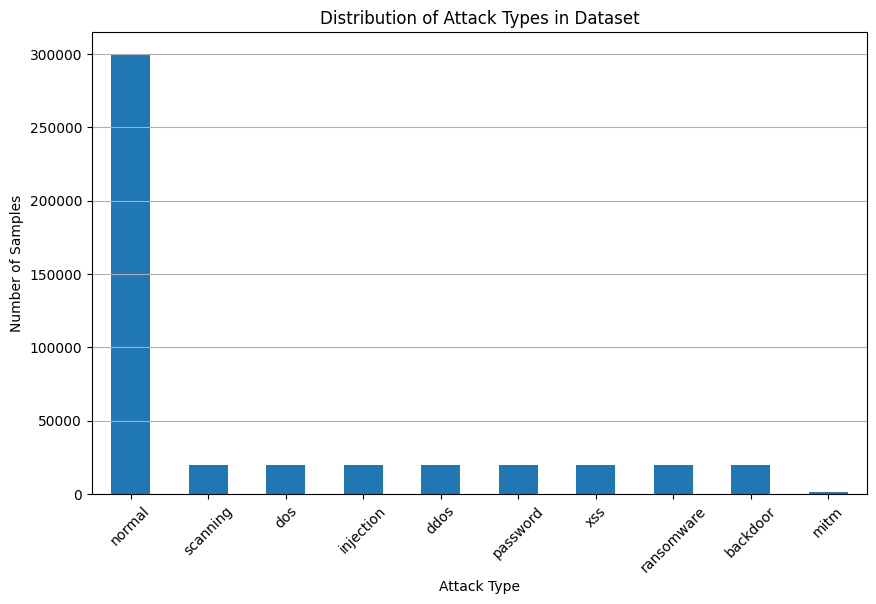

In [2]:
# Distribution of attack types
attack_counts = analysis_df['type'].value_counts()

plt.figure(figsize=(10,6))
attack_counts.plot(kind='bar')

plt.xlabel("Attack Type")
plt.ylabel("Number of Samples")
plt.title("Distribution of Attack Types in Dataset")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


# **TCP Flooding Analysis**

In [3]:
# Selection of useful columns
analysis_df = analysis_df[['conn_state','proto','type',
                           'dst_pkts','src_pkts',
                           'dst_bytes','src_bytes']].copy()

# Original mapping
category_mapping = {
    'backdoor': 'Other',
    'ddos': 'DoS or DDoS',
    'dos': 'DoS or DDoS',
    'injection': 'Other',
    'mitm': 'Other',
    'normal': 'Other',
    'password': 'Other',
    'ransomware': 'Other',
    'scanning': 'Other',
    'xss': 'Other'
}

# Apply mapping
analysis_df['type'] = analysis_df['type'].replace(category_mapping)

# Protocol used
type_proto_counts = (
    analysis_df
    .groupby('type')['proto']
    .value_counts()
    .unstack(fill_value=0)
)

print(type_proto_counts)

proto        icmp     tcp     udp
type                             
DoS or DDoS     0   33250    6750
Other        5880  248826  166337


In [4]:
# Shuffle dataset and split it in train-test sets
clean_df = analysis_df.sample(frac=1, random_state=42)
train_df, test_df = train_test_split(clean_df, train_size=0.8)

In [5]:
# Map TCP connection states into Suspicious/Normal categories
conn_state_map = {
    'S0':'Suspicious',
    'REJ':'Suspicious',
    'RSTO':'Suspicious',
    'RSTR':'Suspicious',
    'SH':'Suspicious',
    'SF':'Normal',
    'S1':'Normal',
    'S2':'Normal',
    'S3':'Normal',
    'OTH':'Normal'
}

tcp_mask = train_df['proto'] == 'tcp'
train_df.loc[tcp_mask,'conn_state'] = \
train_df.loc[tcp_mask,'conn_state'].replace(conn_state_map)


# Split training data into fixed-size subsets for window-based analysis
subset_size = 1000
subsets = [train_df.iloc[i:i+subset_size]
           for i in range(0,len(train_df),subset_size)]


In [6]:
# Compute percentage of Suspicious and Normal TCP connections per subset
sus = []
normal = []
subset_ids = []

for i,sub in enumerate(subsets,1):
    s = len(sub[sub['conn_state']=='Suspicious'])
    n = len(sub[sub['conn_state']=='Normal'])
    tot = s+n

    subset_ids.append(i)
    if tot>0:
        sus.append(s*100/tot)
        normal.append(n*100/tot)
    else:
        sus.append(0)
        normal.append(100)

# Compute global threshold separating Suspicious and Normal TCP behavior
threshold_tcp = (np.mean(sus) + np.mean(normal)) / 2
print("TCP Threshold:", threshold_tcp)

TCP Threshold: 50.0


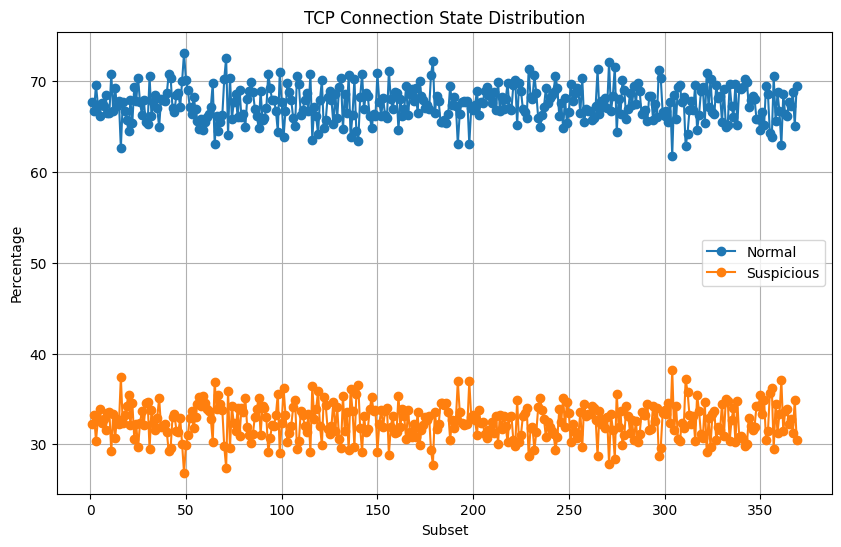

In [7]:
# Plotting TCP connection State distribution across subsets
plt.figure(figsize=(10,6))
plt.plot(subset_ids, normal, marker='o', label="Normal")
plt.plot(subset_ids, sus, marker='o', label="Suspicious")
plt.xlabel("Subset")
plt.ylabel("Percentage")
plt.title("TCP Connection State Distribution")
plt.legend()
plt.grid()
plt.show()


# **UDP Flooding** - DoS/DDoS Attacks vs Other

In [ ]:
# Mean values of source/destination packets and source/destination bytes for DoS/DDoS attacks and "Other" attacks

mean_dst_pkts_DoS = []
mean_dst_pkts_not_DoS = []

mean_src_pkts_DoS = []
mean_src_pkts_not_DoS = []

mean_dst_bytes_DoS = []
mean_dst_bytes_not_DoS = []

mean_src_bytes_DoS = []
mean_src_bytes_not_DoS = []


for subset in subsets:

    udp_subset = subset[subset['proto'] == 'udp']

    dos = udp_subset[udp_subset['type'] == 'DoS or DDoS']
    other = udp_subset[udp_subset['type'] == 'Other']

    mean_dst_pkts_DoS.append(dos['dst_pkts'].mean())
    mean_dst_pkts_not_DoS.append(other['dst_pkts'].mean())

    mean_src_pkts_DoS.append(dos['src_pkts'].mean())
    mean_src_pkts_not_DoS.append(other['src_pkts'].mean())

    mean_dst_bytes_DoS.append(dos['dst_bytes'].mean())
    mean_dst_bytes_not_DoS.append(other['dst_bytes'].mean())

    mean_src_bytes_DoS.append(dos['src_bytes'].mean())
    mean_src_bytes_not_DoS.append(other['src_bytes'].mean())

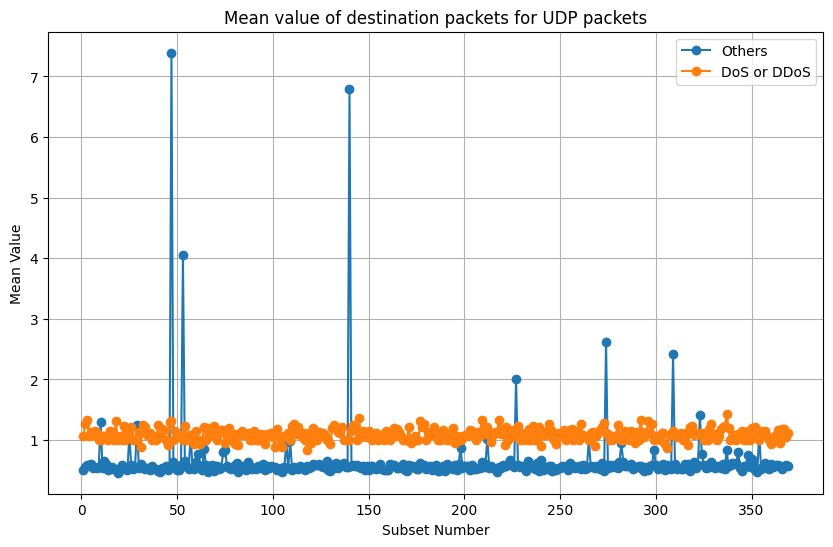

In [9]:
subset_numbers = list(range(1, len(subsets)+1))

# Destination packets
plt.figure(figsize=(10,6))
plt.plot(subset_numbers, mean_dst_pkts_not_DoS, marker='o', label='Others')
plt.plot(subset_numbers, mean_dst_pkts_DoS, marker='o', label='DoS or DDoS')
plt.xlabel("Subset Number")
plt.ylabel("Mean Value")
plt.title("Mean value of destination packets for UDP packets")
plt.legend()
plt.grid()
plt.show()


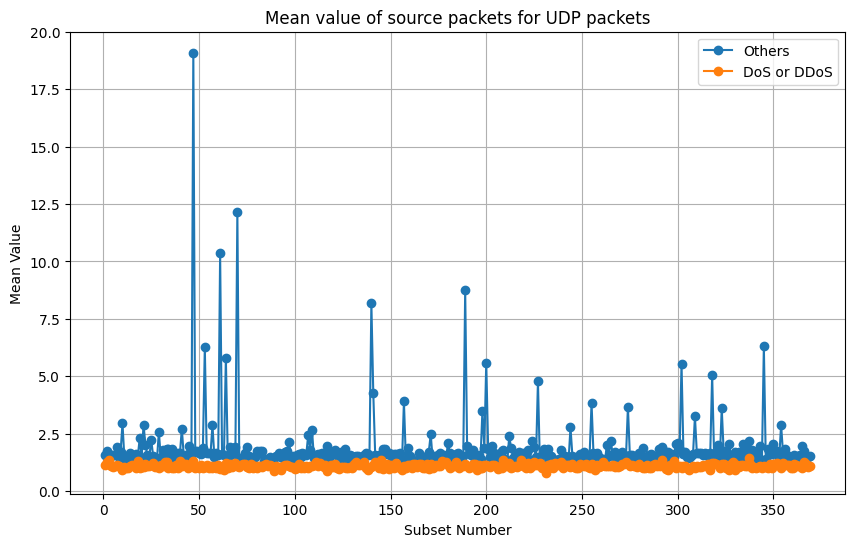

In [10]:
# Source packets
plt.figure(figsize=(10,6))
plt.plot(subset_numbers, mean_src_pkts_not_DoS, marker='o', label='Others')
plt.plot(subset_numbers, mean_src_pkts_DoS, marker='o', label='DoS or DDoS')
plt.xlabel("Subset Number")
plt.ylabel("Mean Value")
plt.title("Mean value of source packets for UDP packets")
plt.legend()
plt.grid()
plt.show()

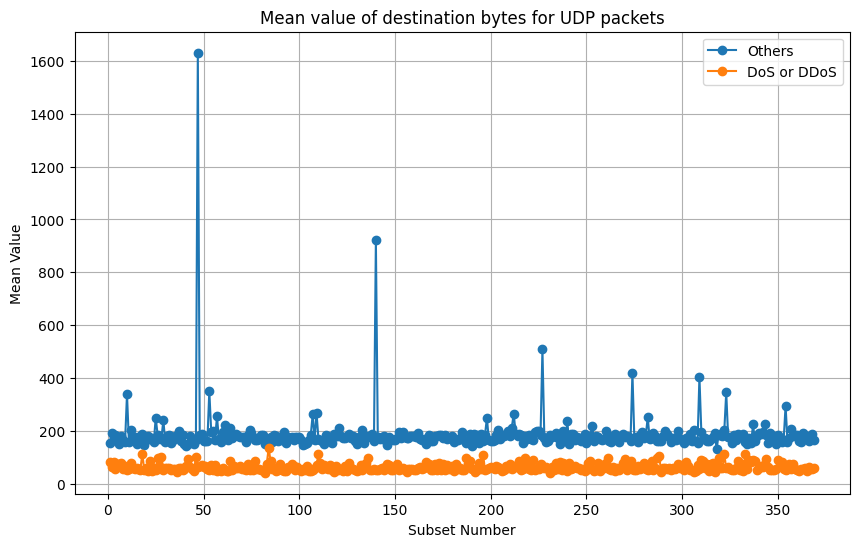

In [11]:
# Destination bytes
plt.figure(figsize=(10,6))
plt.plot(subset_numbers, mean_dst_bytes_not_DoS, marker='o', label='Others')
plt.plot(subset_numbers, mean_dst_bytes_DoS, marker='o', label='DoS or DDoS')
plt.xlabel("Subset Number")
plt.ylabel("Mean Value")
plt.title("Mean value of destination bytes for UDP packets")
plt.legend()
plt.grid()
plt.show()

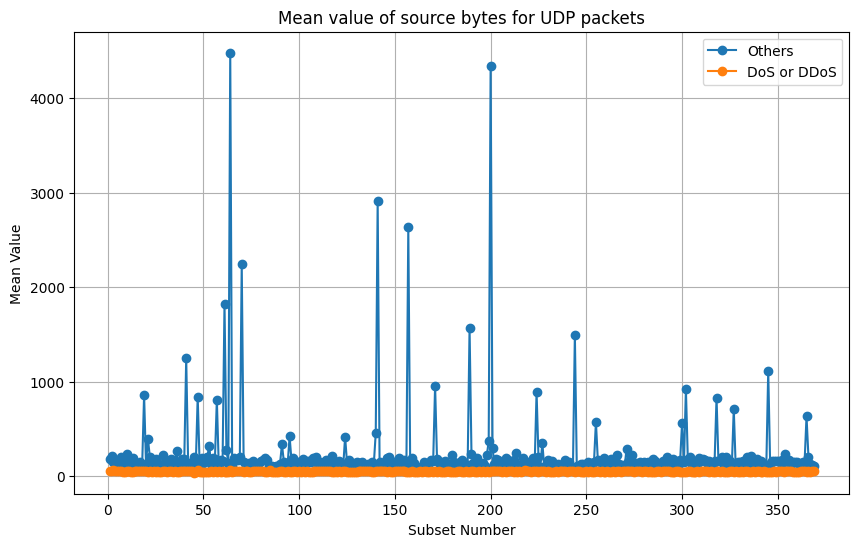

In [12]:
# Source bytes
plt.figure(figsize=(10,6))
plt.plot(subset_numbers, mean_src_bytes_not_DoS, marker='o', label='Others')
plt.plot(subset_numbers, mean_src_bytes_DoS, marker='o', label='DoS or DDoS')
plt.xlabel("Subset Number")
plt.ylabel("Mean Value")
plt.title("Mean value of source bytes for UDP packets")
plt.legend()
plt.grid()
plt.show()

In [13]:
# Compute global UDP Flooding thresholds

threshold_dst_pkts = (np.nanmean(mean_dst_pkts_DoS) +
                      np.nanmean(mean_dst_pkts_not_DoS)) / 2

threshold_src_pkts = (np.nanmean(mean_src_pkts_DoS) +
                      np.nanmean(mean_src_pkts_not_DoS)) / 2

threshold_dst_bytes = (np.nanmean(mean_dst_bytes_DoS) +
                       np.nanmean(mean_dst_bytes_not_DoS)) / 2

threshold_src_bytes = (np.nanmean(mean_src_bytes_DoS) +
                       np.nanmean(mean_src_bytes_not_DoS)) / 2

print(f"Threshold mean destination packets: {threshold_dst_pkts:.4f}")
print(f"Threshold mean source packets: {threshold_src_pkts:.4f}")
print(f"Threshold mean destination bytes: {threshold_dst_bytes:.4f}")
print(f"Threshold mean source bytes: {threshold_src_bytes:.4f}")


Threshold mean destination packets: 0.8648
Threshold mean source packets: 1.4864
Threshold mean destination bytes: 124.3926
Threshold mean source bytes: 139.8145


In [14]:
# Evaluate UDP flooding behavior using threshold-based volumetric statistics

percent_dst_pkts_higher = []
percent_src_pkts_lower = []
percent_dst_bytes_lower = []
percent_src_bytes_lower = []

subset_numbers = []

for i, subset in enumerate(subsets, start=1):

    udp_subset = subset[subset['proto']=='udp']
    subset_numbers.append(i)

    if len(udp_subset) > 0:
        percent_dst_pkts_higher.append(
            len(udp_subset[udp_subset['dst_pkts'] > threshold_dst_pkts]) / len(udp_subset)
        )

        percent_src_pkts_lower.append(
            len(udp_subset[udp_subset['src_pkts'] < threshold_src_pkts]) / len(udp_subset)
        )

        percent_dst_bytes_lower.append(
            len(udp_subset[udp_subset['dst_bytes'] < threshold_dst_bytes]) / len(udp_subset)
        )

        percent_src_bytes_lower.append(
            len(udp_subset[udp_subset['src_bytes'] < threshold_src_bytes]) / len(udp_subset)
        )
    else:
        percent_dst_pkts_higher.append(0)
        percent_src_pkts_lower.append(0)
        percent_dst_bytes_lower.append(0)
        percent_src_bytes_lower.append(0)


# Aggregate UDP percentages to obtain global indicators
thresholds_udp = []
thresholds_udp.append(np.mean(percent_dst_pkts_higher))
thresholds_udp.append(np.mean(percent_src_pkts_lower))
thresholds_udp.append(np.mean(percent_dst_bytes_lower))
thresholds_udp.append(np.mean(percent_src_bytes_lower))

print(f'Percentage of packets with higher dst_pkts than threshold: {thresholds_udp[0]:.4f}')
print(f'Percentage of packets with lower src_pkts than threshold: {thresholds_udp[1]:.4f}')
print(f'Percentage of packets with lower dst_bytes than threshold: {thresholds_udp[2]:.4f}')
print(f'Percentage of packets with lower src_bytes than threshold: {thresholds_udp[3]:.4f}')


Percentage of packets with higher dst_pkts than threshold: 0.4693
Percentage of packets with lower src_pkts than threshold: 0.7870
Percentage of packets with lower dst_bytes than threshold: 0.6766
Percentage of packets with lower src_bytes than threshold: 0.9148


## Attack-type comparative Analysis

In [15]:
# Selection of useful columns
multi_df = df[['conn_state','proto','type',
                        'dst_pkts','src_pkts',
                        'dst_bytes','src_bytes']].copy()

# Using a different mapping by grouping similar-behaviour attacks
multi_mapping = {
    'ddos':'DoS or DDoS',
    'dos':'DoS or DDoS',
    'scanning':'Scanning',
    'password':'BruteForce',
    'backdoor':'BruteForce',
    'xss':'WebAttack',
    'injection':'WebAttack',
    'ransomware':'Ransomware',
    'normal':'Normal'
}

# Apply mapping
multi_df['type'] = multi_df['type'].replace(multi_mapping)

print(multi_df['type'].value_counts())


type
Normal         300000
DoS or DDoS     40000
WebAttack       40000
BruteForce      40000
Scanning        20000
Ransomware      20000
mitm             1043
Name: count, dtype: int64


In [16]:
# Initialize containers for per-attack volumetric statistics

attacks = ['DoS or DDoS','Scanning','WebAttack','BruteForce','Ransomware']

mean_dst_pkts = {}
mean_src_pkts = {}
mean_dst_bytes = {}
mean_src_bytes = {}

for attack in attacks:
    mean_dst_pkts[attack] = []
    mean_src_pkts[attack] = []
    mean_dst_bytes[attack] = []
    mean_src_bytes[attack] = []


In [17]:
# Shuffle and split multi-attack dataset into subsets

clean_multi = multi_df.sample(frac=1, random_state=42).reset_index(drop=True)

subset_size = 1000
multi_subsets = [clean_multi.iloc[i:i+subset_size]
                 for i in range(0,len(clean_multi),subset_size)]


In [18]:
# Compute mean packet and byte values per subset for each attack type

for subset in multi_subsets:

    for attack in attacks:

        attack_subset = subset[subset['type'] == attack]

        mean_dst_pkts[attack].append(attack_subset['dst_pkts'].mean())
        mean_src_pkts[attack].append(attack_subset['src_pkts'].mean())
        mean_dst_bytes[attack].append(attack_subset['dst_bytes'].mean())
        mean_src_bytes[attack].append(attack_subset['src_bytes'].mean())


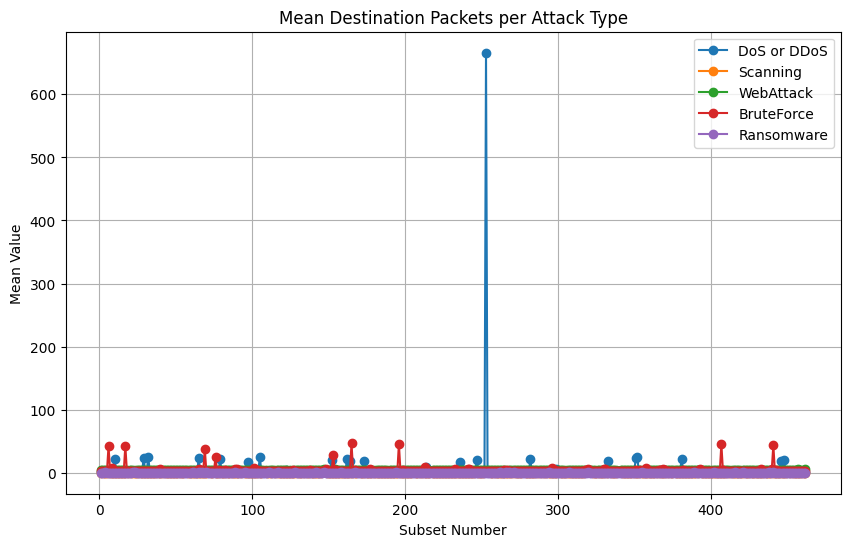

In [19]:
subset_numbers = list(range(1, len(multi_subsets)+1))

# Destination Packets
plt.figure(figsize=(10,6))
for attack in attacks:
    plt.plot(subset_numbers, mean_dst_pkts[attack], marker='o', label=attack)
plt.xlabel("Subset Number")
plt.ylabel("Mean Value")
plt.title("Mean Destination Packets per Attack Type")
plt.legend()
plt.grid()
plt.show()


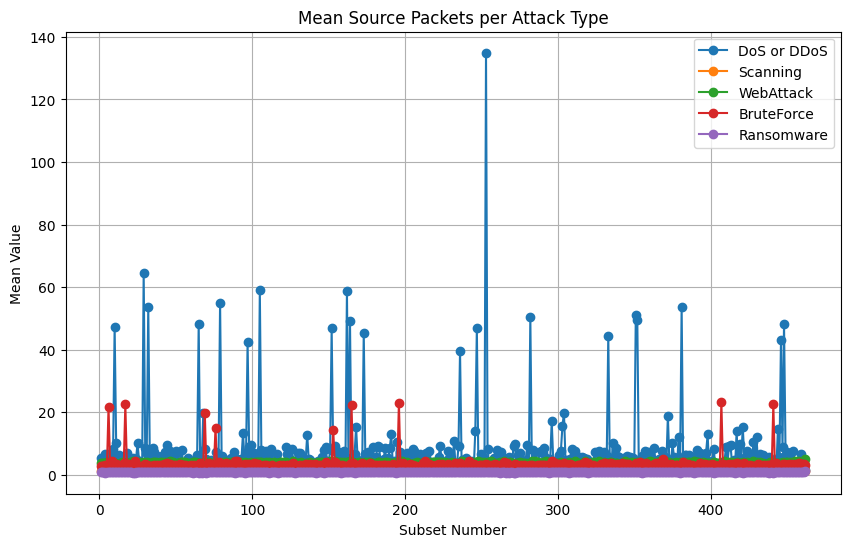

In [20]:
# Source Packets
plt.figure(figsize=(10,6))
for attack in attacks:
    plt.plot(subset_numbers, mean_src_pkts[attack], marker='o', label=attack)
plt.xlabel("Subset Number")
plt.ylabel("Mean Value")
plt.title("Mean Source Packets per Attack Type")
plt.legend()
plt.grid()
plt.show()

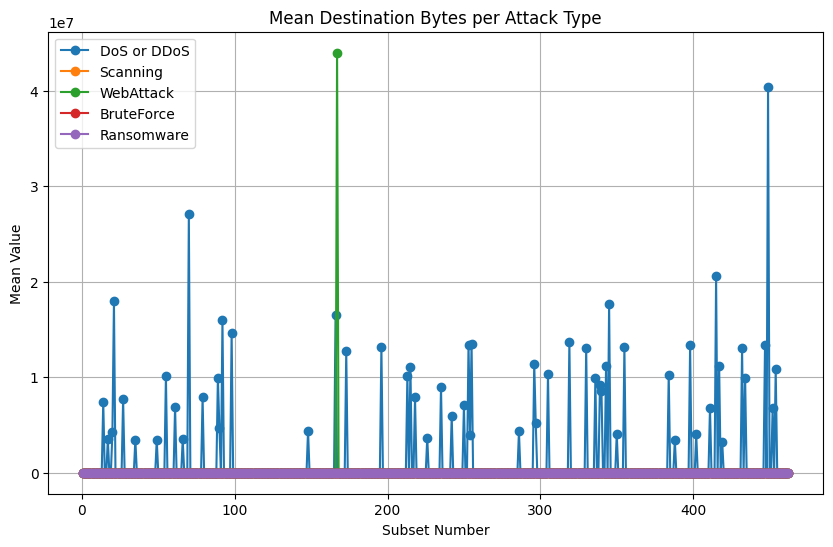

In [21]:
# Destination Bytes
plt.figure(figsize=(10,6))
for attack in attacks:
    plt.plot(subset_numbers, mean_dst_bytes[attack], marker='o', label=attack)
plt.xlabel("Subset Number")
plt.ylabel("Mean Value")
plt.title("Mean Destination Bytes per Attack Type")
plt.legend()
plt.grid()
plt.show()

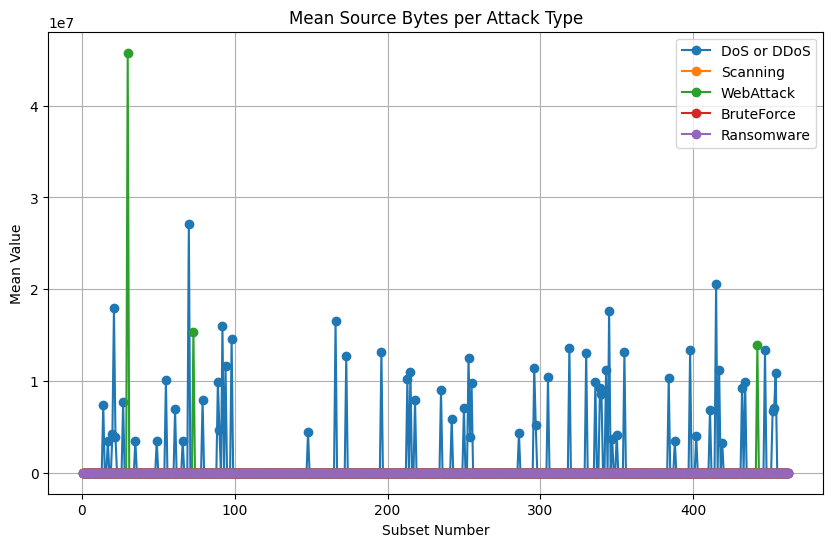

In [22]:
# Source Bytes
plt.figure(figsize=(10,6))
for attack in attacks:
    plt.plot(subset_numbers, mean_src_bytes[attack], marker='o', label=attack)
plt.xlabel("Subset Number")
plt.ylabel("Mean Value")
plt.title("Mean Source Bytes per Attack Type")
plt.legend()
plt.grid()
plt.show()

# **Machine Learning Models evaluation** -  DoS/DDoS Attacks vs Other

## Original dataset Analysis

In [44]:
# Feature selection

ml_df = train_df[['proto','dst_pkts','src_pkts','dst_bytes','src_bytes','type']].copy()

ml_df = pd.get_dummies(ml_df, columns=['proto'])

ml_df['label'] = ml_df['type'].map({
    'DoS or DDoS':1,
    'Other':0
})


X = ml_df.drop(['type','label'], axis=1)
y = ml_df['label']

In [45]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [46]:
# Defining models

rf = RandomForestClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression(max_iter=1000)
svm = LinearSVC()

In [47]:
# Training models

rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)


LinearSVC()

In [48]:
# Testing models

rf_pred = rf.predict(X_test)
lr_pred = lr.predict(X_test)
svm_pred = svm.predict(X_test)


In [49]:
# Metrics

rf_acc = accuracy_score(y_test, rf_pred)
lr_acc = accuracy_score(y_test, lr_pred)
svm_acc = accuracy_score(y_test, svm_pred)

rf_rec = recall_score(y_test, rf_pred)
lr_rec = recall_score(y_test, lr_pred)
svm_rec = recall_score(y_test, svm_pred)

rf_f1 = f1_score(y_test, rf_pred)
lr_f1 = f1_score(y_test, lr_pred)
svm_f1 = f1_score(y_test, svm_pred)


In [50]:
# Print metrics

print("Precision\n")
print(f"Random Forest: {rf_acc:.4f}")
print(f"LR: {lr_acc:.4f}")
print(f"SVM: {svm_acc:.4f}")

print("\n\nRecall\n")
print(f"Random Forest: {rf_rec:.4f}")
print(f"LR: {lr_rec:.4f}")
print(f"SVM: {svm_rec:.4f}")


print("\n\nF1 Score\n")
print(f"Random Forest: {rf_f1:.4f}")
print(f"LR: {lr_f1:.4f}")
print(f"SVM: {svm_f1:.4f}")

Precision

Random Forest: 0.9582
LR: 0.9148
SVM: 0.9148


Recall

Random Forest: 0.5547
LR: 0.0021
SVM: 0.0022


F1 Score

Random Forest: 0.6935
LR: 0.0041
SVM: 0.0044


## **SMOTE** (Synthetic Minority Over-sampling Technique) application on dataset Analysis

In [51]:
# Feature selection

ml_df = train_df[['proto','dst_pkts','src_pkts',
                  'dst_bytes','src_bytes','type']].copy()

ml_df = pd.get_dummies(ml_df, columns=['proto'])

ml_df['label'] = ml_df['type'].map({
    'DoS or DDoS':1,
    'Other':0
})

X = ml_df.drop(['type','label'], axis=1)
y = ml_df['label']

In [52]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [53]:
# Apply SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_train_bal).value_counts())

Class distribution after SMOTE:
label
0    269306
1    269306
Name: count, dtype: int64


In [54]:
# Defining models

rf = RandomForestClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression(max_iter=1000)
svm = LinearSVC()

In [55]:
# Training models on balanced data

rf.fit(X_train_bal, y_train_bal)
lr.fit(X_train_bal, y_train_bal)
svm.fit(X_train_bal, y_train_bal)

LinearSVC()

In [56]:
# Prediction on original test set

rf_pred = rf.predict(X_test)
lr_pred = lr.predict(X_test)
svm_pred = svm.predict(X_test)

In [57]:
# Metrics

rf_acc = accuracy_score(y_test, rf_pred)
lr_acc = accuracy_score(y_test, lr_pred)
svm_acc = accuracy_score(y_test, svm_pred)

rf_rec = recall_score(y_test, rf_pred)
lr_rec = recall_score(y_test, lr_pred)
svm_rec = recall_score(y_test, svm_pred)

rf_f1 = f1_score(y_test, rf_pred)
lr_f1 = f1_score(y_test, lr_pred)
svm_f1 = f1_score(y_test, svm_pred)

In [58]:
# Print metrics

print("Precision\n")
print(f"Random Forest: {rf_acc:.4f}")
print(f"LR: {lr_acc:.4f}")
print(f"SVM: {svm_acc:.4f}")

print("\n\nRecall\n")
print(f"Random Forest: {rf_rec:.4f}")
print(f"LR: {lr_rec:.4f}")
print(f"SVM: {svm_rec:.4f}")


print("\n\nF1 Score\n")
print(f"Random Forest: {rf_f1:.4f}")
print(f"LR: {lr_f1:.4f}")
print(f"SVM: {svm_f1:.4f}")

Precision

Random Forest: 0.9192
LR: 0.3856
SVM: 0.1228


Recall

Random Forest: 0.9795
LR: 0.7550
SVM: 0.2623


F1 Score

Random Forest: 0.6740
LR: 0.1734
SVM: 0.0486
